# Test Landmarks

In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed

from itertools import combinations
import face_recognition

2023-05-17 17:39:19.336974: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-17 17:39:19.385909: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
TESTING_COHERENCE_LOSS = "l1"
TESTING_MAIN_LOSS = "l1"

# Dimensions
BATCH_SIZE = 20
IMG_WIDTH = 64
IMG_HEIGHT = 64
N_CHANNELS = 3


STEPS = 100000

LAMBDA1 = 1000
LAMBDA2 = 200

VIDEOS_FOLDER = 'mug64'

In [3]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [4]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def plot_frame(frame, title=None):
    plt.imshow(frame)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()
    plt.close()

def plot_normalized_frame(frame, title=None):
    plot_frame(normalized_sequence_to_images(frame), title)

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

In [5]:
videos_path = list(Path(f'../data/{VIDEOS_FOLDER}/').glob('**/*.npy'))

In [6]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

print(len(train_paths))
print(len(test_paths))

722
310


In [7]:
class FrameDataGenerator():
    
    def __init__(self, videos_path, batch_size=1):
        self.videos_path = videos_path
        self.n = len(videos_path)
        self._restart()
        self.batch_size = batch_size
    
    def _load_current_video(self):
        self.current_video = np.load(self.videos_path[self.current_video_index])
    
    def __iter__(self):
        return self
    
    def _load_next_video(self):
        self.current_frame_index = 1
        #pick a random video index
        self.current_video_index = self.current_video_index + self.batch_size
        self._load_current_video()
    
    def _restart(self):
        self.current_video_index = 0
        self.current_frame_index = 0
        self._load_current_video()
    

    def _current_frame(self):
        return self.current_video[self.current_frame_index]
    
    def _next_frame(self):
        return self.current_video[self.current_frame_index+self.batch_size]
    
    def _previous_frame(self):
        return self.current_video[self.current_frame_index-self.batch_size]
    
    def _current_video_has_next_frame(self):
        return self.current_frame_index+self.batch_size < self.current_video.shape[0]
    
    def _has_current_video(self):
        return self.current_video_index < self.n
    
    def _has_next_video(self):
        return self.current_video_index+self.batch_size < self.n
    
    def _end_of_videos(self):
            raise StopIteration
    
    def _get_current_frames(self):
        return self._previous_frame(), self._current_frame(), self._next_frame()
    
    def _get_batch(self):
        batch_previous_frame = []
        batch_current_frame = []
        batch_next_frame = []
        for i in range(self.batch_size):
            previous_frame, current_frame, next_frame = self._get_current_frames()
            batch_previous_frame.append(previous_frame)
            batch_current_frame.append(current_frame)
            batch_next_frame.append(next_frame)
        return np.array(batch_previous_frame), np.array(batch_current_frame), np.array(batch_next_frame)


    def __next__(self):
        self.current_frame_index += self.batch_size # Frame index start at one because we have to return the previous frame
        self._load_next_video()
        if not self._has_current_video():
            self._end_of_videos()
        while not self._current_video_has_next_frame():
            if self._has_next_video():
                self._load_next_video()
            else:
                self._end_of_videos()
        return self._get_batch()
    
    def __call__(self):
        return next(self)
    
    def take(self, n):
        for i in range(n):
            try:
                yield self()
            except StopIteration:
                self._restart()
    
    def __iter__(self):
        return self
    
    def repeat(self):
        while True:
            try:
                yield self()
            except StopIteration:
                self._restart()

In [8]:
train_generator = FrameDataGenerator(train_paths, batch_size=20)
test_generator = FrameDataGenerator(test_paths, batch_size=20)

previous_frame, current_frame, next_frame = next(train_generator)
previous_frame2, current_frame2, next_frame2 = next(train_generator)
previous_frame3, current_frame3, next_frame3 = next(train_generator)
previous_frame4, current_frame4, next_frame4 = next(train_generator)
print(previous_frame.shape)
print(current_frame.shape)
print(next_frame.shape)

print(train_generator.current_video_index)
print(train_generator.current_frame_index)
print(train_generator.current_video.shape)

(20, 64, 64, 3)
(20, 64, 64, 3)
(20, 64, 64, 3)
80
1
(60, 64, 64, 3)


2023-05-17 17:39:24.333966: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 220 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


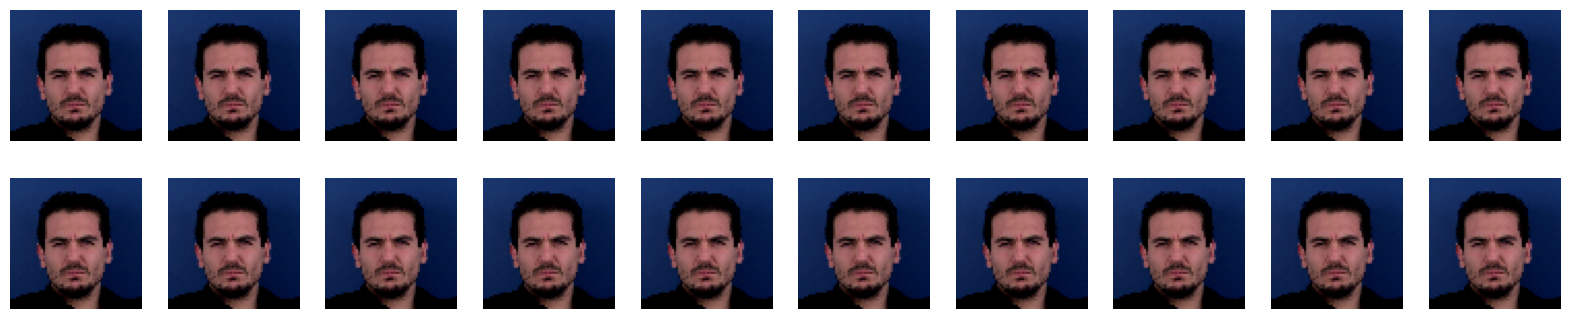

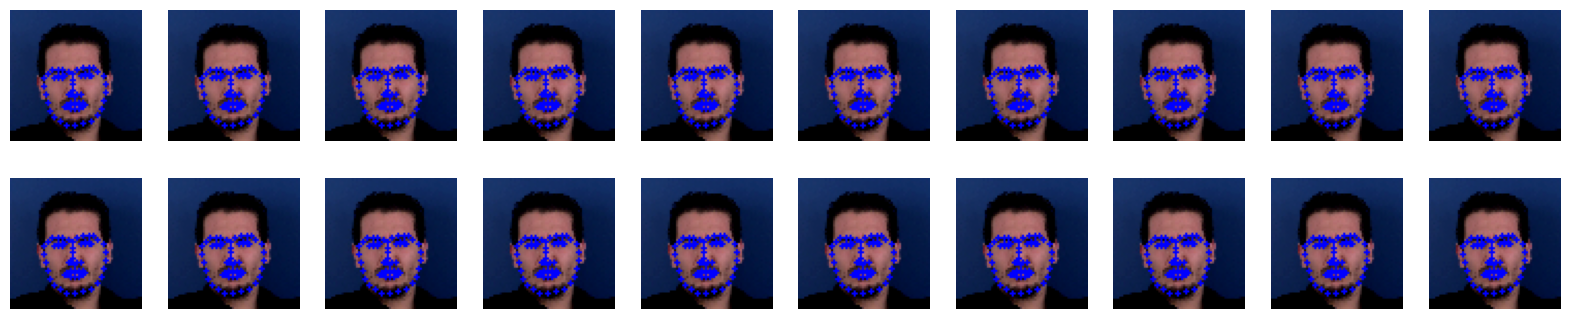

In [9]:
out_frames = []
out_landmarks = []

for image in previous_frame4:
    
    image =  normalized_sequence_to_images(image)
    image = np.array(image, dtype=np.uint8)

    bboxes = face_recognition.api.face_locations(image)
    faces = face_recognition.api._raw_face_landmarks(face_image=image)
    landmarks = np.array([(p.x, p.y) for p in faces[0].parts()])
    out_landmarks.append(landmarks)
                
    if len(faces) > 0:
      for l in faces[0].parts():
        cv2.circle(image, (int(l.x), int(l.y)), 1, (0, 0, 255), -1)
    else:
      print("No Face Detected")
     
    out_frames.append(image)
 
out_frames = np.array(out_frames)
out_landmarks = np.array(out_landmarks)

plot_normalized_sequence(previous_frame4)
plot_sequence(out_frames)

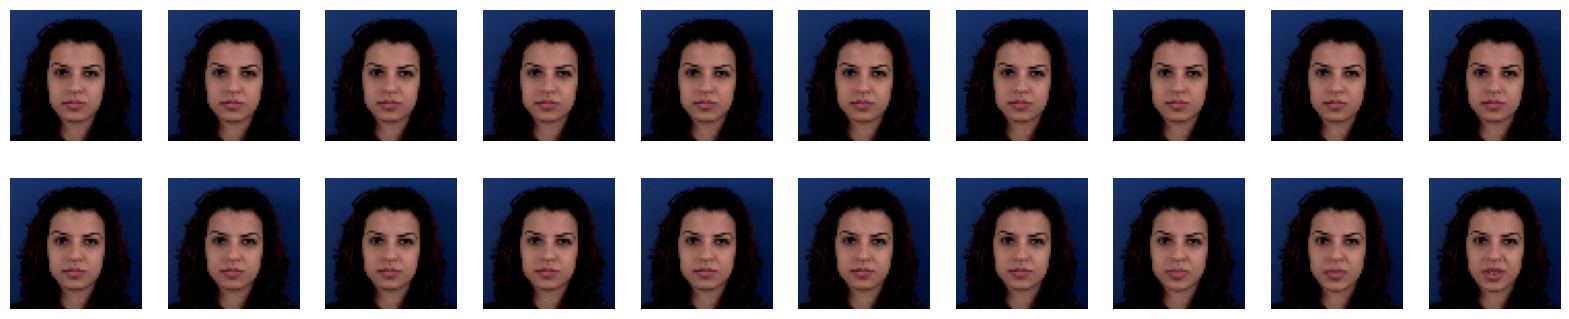

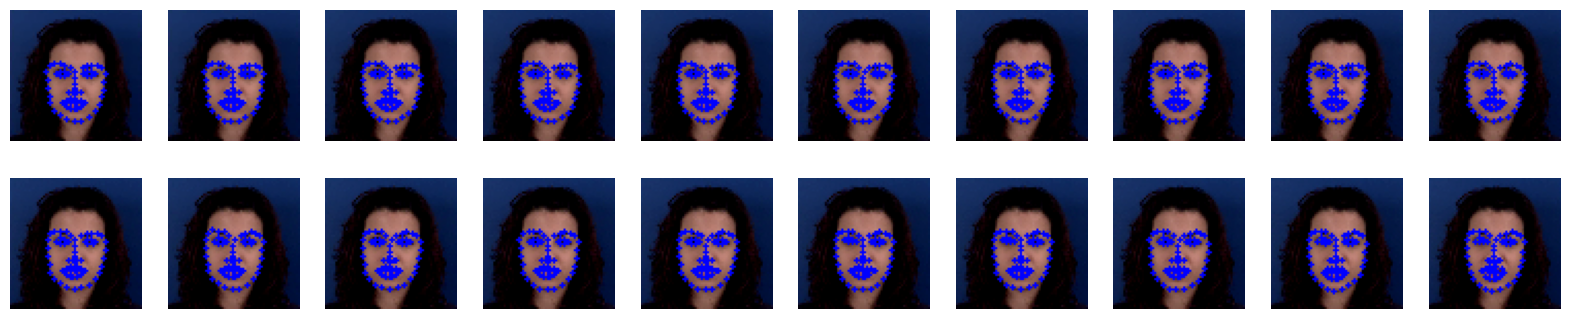

(96, 64, 64, 3)
(96, 68, 2)


In [10]:
current_video = np.load("../data/mug64/001/happiness/take001/video.npy")

out_frames2 = []
out_landmarks2 = []

for image in current_video:
    
    image =  normalized_sequence_to_images(image)
    image = np.array(image, dtype=np.uint8)

    bboxes = face_recognition.api.face_locations(image)
    faces = face_recognition.api._raw_face_landmarks(face_image=image)
    landmarks = np.array([(p.x, p.y) for p in faces[0].parts()])
    out_landmarks2.append(landmarks)
                
    if len(faces) > 0:
      for l in faces[0].parts():
        cv2.circle(image, (int(l.x), int(l.y)), 1, (0, 0, 255), -1)
    else:
      print("No Face Detected")
     
    out_frames2.append(image)
 
out_frames2 = np.array(out_frames2)
out_landmarks2 = np.array(out_landmarks2)

plot_normalized_sequence(current_video)
plot_sequence(out_frames2)
print(current_video.shape)
print(out_landmarks2.shape)

In [11]:
out_landmarks.shape

(20, 68, 2)

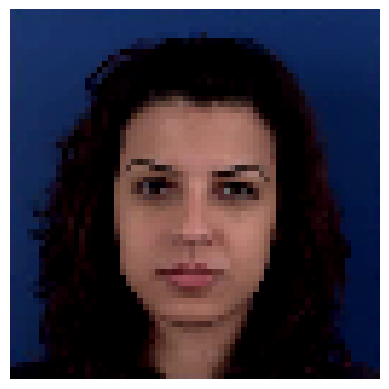

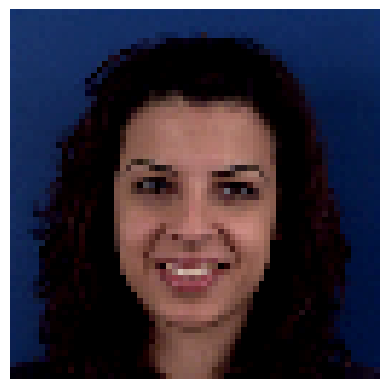

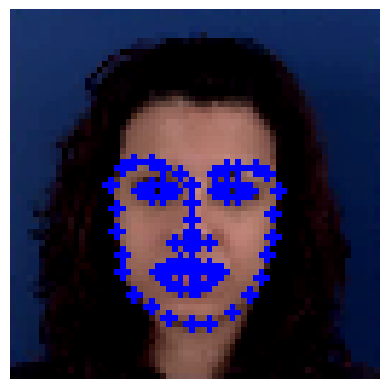

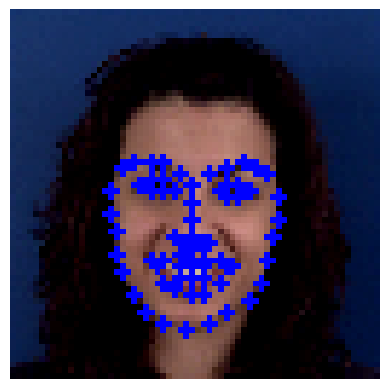

In [12]:
plot_normalized_frame(current_video[0])
plot_normalized_frame(current_video[72])

image = current_video[0]
image =  normalized_sequence_to_images(image)
image = np.array(image, dtype=np.uint8)
bboxes = face_recognition.api.face_locations(image)
faces = face_recognition.api._raw_face_landmarks(face_image=image)
landmarks = np.array([(p.x, p.y) for p in faces[0].parts()])
            
if len(faces) > 0:
    for l in faces[0].parts():
        cv2.circle(image, (int(l.x), int(l.y)), 1, (0, 0, 255), -1)

plot_frame(image)

image = current_video[72]
image =  normalized_sequence_to_images(image)
image = np.array(image, dtype=np.uint8)
bboxes = face_recognition.api.face_locations(image)
faces = face_recognition.api._raw_face_landmarks(face_image=image)
landmarks = np.array([(p.x, p.y) for p in faces[0].parts()])
            
if len(faces) > 0:
    for l in faces[0].parts():
        cv2.circle(image, (int(l.x), int(l.y)), 1, (0, 0, 255), -1)

plot_frame(image)

/tmp/ipykernel_6943/2872472611.py:44: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  plt.plot(points_a[:, 0], points_a[:, 1], "ok", label="previous landmarks", color="black")
/tmp/ipykernel_6943/2872472611.py:45: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  plt.plot(points_b[:, 0], points_b[:, 1], "ok", label="current landmarks", color="blue")


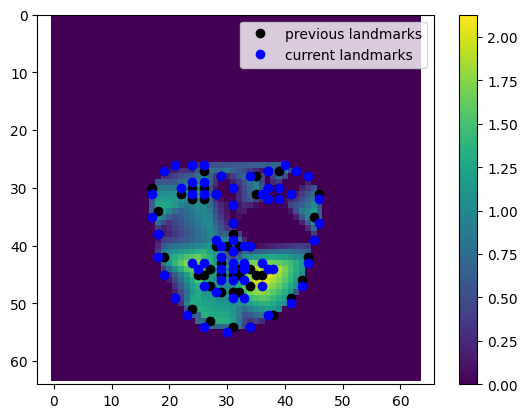

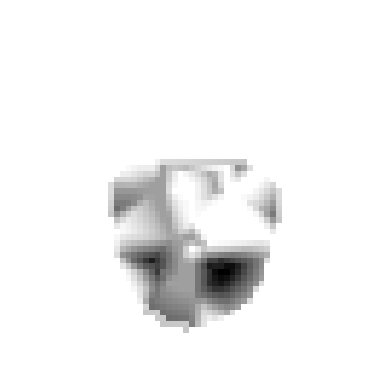

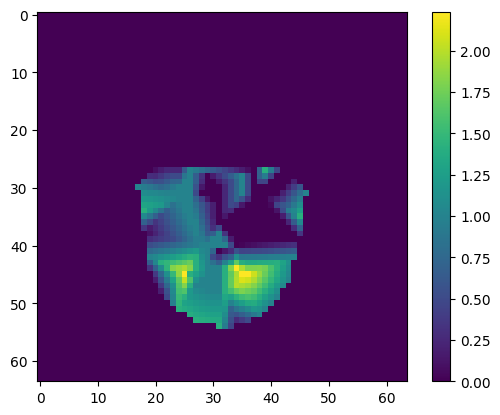

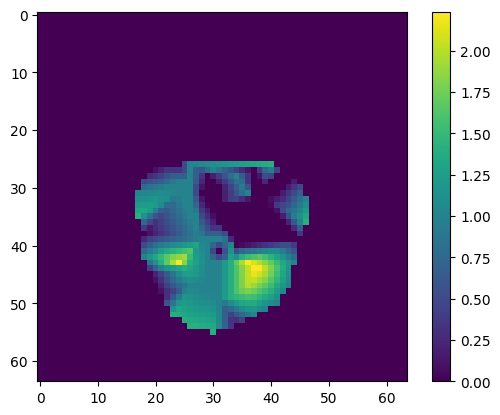

In [20]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import gaussian_filter


def draw_vectors(displacements_map):
    # flip the y axis to match the image coordinates
    displacements_map = displacements_map[::-1]
    #rescale between 0 and 1
    displacements_map = displacements_map - np.min(displacements_map)
    x,y = np.meshgrid(np.arange(0,displacements_map.shape[0]), np.arange(0,displacements_map.shape[1]))
    v, u = displacements_map[...,0], displacements_map[...,1]
    fig, ax = plt.subplots()
    q = ax.quiver(x,y,u,v)
    plt.show()

def compute_displacements_interpolation(points_a, points_b, image_height=IMG_HEIGHT, image_width=IMG_WIDTH):
    """
    Computes the interpolation for all points of the displacements by the distance between the vertices of points_a and Points_b.
    Assumes that the input vertices and displacements are arrays of shape (num_triangles, 3, 2),
    where num_triangles is the number of triangles and each triangle is defined by three (x, y) vertex coordinates.
    Assumes that the input x and y are arrays of shape (height, width), representing the 2D grid of points to compute the displacements for.
    Returns an array of shape (height, width, 2), representing the displacements of each point on the grid.
    """
   
    points_a = np.asarray(points_a)
    points_b = np.asarray(points_b)

    # computer eucliden distance between points_a and points_b
    displacements_values = np.linalg.norm(points_b - points_a, axis=1)
    

    interpolator_a = LinearNDInterpolator(points_a, displacements_values, fill_value=0)
    interpolator_b = LinearNDInterpolator(points_b, displacements_values, fill_value=0)
    X = np.arange(0, image_height)
    Y = np.arange(0, image_width)
    X, Y = np.meshgrid(X, Y)
    displacements_map_a = interpolator_a(X, Y)
    displacements_map_b = interpolator_b(X, Y)
    displacements_map = np.mean([displacements_map_a, displacements_map_b], axis=0)


    plt.pcolormesh(X, Y, displacements_map, shading='auto')
    plt.plot(points_a[:, 0], points_a[:, 1], "ok", label="previous landmarks", color="black")
    plt.plot(points_b[:, 0], points_b[:, 1], "ok", label="current landmarks", color="blue")
    plt.legend()
    plt.colorbar()
    plt.axis("equal")
    plt.ylim(IMG_HEIGHT, 0)
    plt.show()

    
    plt.imshow(displacements_map, cmap='Greys')
    # plt.colorbar()
    plt.axis('off')
    plt.show()

    plt.imshow(displacements_map_a)
    plt.colorbar()
    plt.show()

    plt.imshow(displacements_map_b)
    plt.colorbar()
    plt.show()
    

    return displacements_map

displacements_map = compute_displacements_interpolation(out_landmarks2[0], out_landmarks2[72])

/tmp/ipykernel_6943/3535859995.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  plt.plot(points_a[:, 0], points_a[:, 1], "ok", label="previous landmarks", color="black")
/tmp/ipykernel_6943/3535859995.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ok" (-> color='k'). The keyword argument will take precedence.
  plt.plot(points_b[:, 0], points_b[:, 1], "ok", label="current landmarks", color="blue")


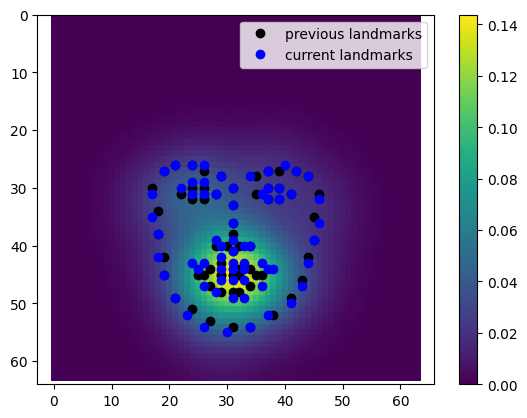

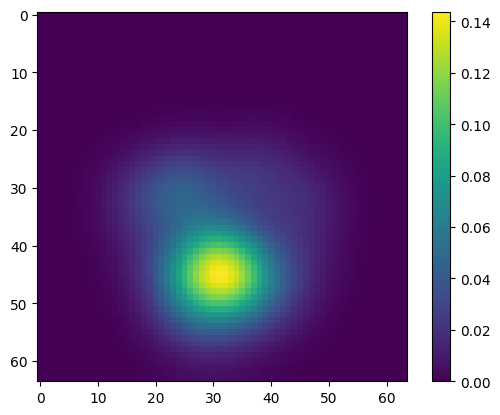

In [14]:
from scipy.ndimage import gaussian_filter

def compute_displacements_guassian(points_a, points_b, kernel_size, sigma=5, muu=0, image_height=IMG_HEIGHT, image_width=IMG_WIDTH):
    """
    Computes the interpolation for all points of the displacements by the distance between the vertices of points_a and Points_b.
    Assumes that the input vertices and displacements are arrays of shape (num_triangles, 3, 2),
    where num_triangles is the number of triangles and each triangle is defined by three (x, y) vertex coordinates.
    Assumes that the input x and y are arrays of shape (height, width), representing the 2D grid of points to compute the displacements for.
    Returns an array of shape (height, width, 2), representing the displacements of each point on the grid.
    """
   
    points_a = np.asarray(points_a)
    points_b = np.asarray(points_b)

    # computer eucliden distance between points_a and points_b
    displacements_values = np.linalg.norm(points_b - points_a, axis=1)

    displacements_map = np.zeros((image_height, image_width))
    displacements_map[points_a[:, 1], points_a[:, 0]] = displacements_values

    # gaussian filter
    displacements_map = gaussian_filter(displacements_map, sigma=sigma)


    X = np.arange(0, image_height)
    Y = np.arange(0, image_width)
    X, Y = np.meshgrid(X, Y)


    plt.pcolormesh(X, Y, displacements_map, shading='auto')
    plt.plot(points_a[:, 0], points_a[:, 1], "ok", label="previous landmarks", color="black")
    plt.plot(points_b[:, 0], points_b[:, 1], "ok", label="current landmarks", color="blue")
    plt.legend()
    plt.colorbar()
    plt.axis("equal")
    plt.ylim(IMG_HEIGHT, 0)
    plt.show()

    
    plt.imshow(displacements_map)
    plt.colorbar()
    plt.show()
    

    return displacements_map

displacements_map = compute_displacements_guassian(out_landmarks2[0], out_landmarks2[72], 5)
 

In [15]:
import tensorflow_probability as tfp

x_grid = tf.linspace(0., 1., 20)**2   # Nonlinearly spaced
y_ref = tf.exp(x_grid)

tfp.math.batch_interp_rectilinear_nd_grid(
    # x.shape = [3, 1], with the trailing `1` for `1-D`.
    [[6.0], [0.5], [3.3]], (x_grid,), y_ref, 0)

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([2.7182817, 1.649853 , 2.7182817], dtype=float32)>

In [16]:
x0_grid = tf.range(0., 64.)
x1_grid = tf.range(0., 64.)

# Build y_ref.
x0s, x1s = tf.meshgrid(x0_grid, x1_grid, indexing='ij')

def func(x0, x1):
  return tf.sin(x0) * tf.cos(x1)

y_ref = func(x0s, x1s)

x = np.pi * tf.random.uniform(shape=(68, 2))
x_grid_points = (x0_grid, x1_grid)

r = tfp.math.batch_interp_rectilinear_nd_grid(x, x_grid_points, y_ref, -2)

tf.print(x0s.shape)
tf.print(x1s.shape)
tf.print()
tf.print(r)
tf.print(r.shape)
tf.print()
tf.print(x)
tf.print(x.shape)
tf.print()
tf.print(y_ref)
tf.print(y_ref.shape)
tf.print()

TensorShape([64, 64])
TensorShape([64, 64])

[-0.222624511 0.217326462 0.816125214 ... 0.464504182 -0.463963598 -0.0566686541]
TensorShape([68])

[[0.334834 2.65173197]
 [0.543304503 1.06789076]
 [1.06573319 0.0766428635]
 ...
 [0.6407516 0.301261336]
 [1.60258234 2.19114041]
 [1.9265691 1.63042235]]
TensorShape([68, 2])

[[0 0 -0 ... -0 0 0]
 [0.841471 0.454648703 -0.35017547 ... -0.21718505 0.566736817 0.829603374]
 [0.909297466 0.491295487 -0.37840125 ... -0.234691173 0.612418413 0.896473289]
 ...
 [-0.966117799 -0.521995664 0.402046859 ... 0.249356598 -0.650687277 -0.952492237]
 [-0.739180684 -0.399381 0.307607681 ... 0.190783754 -0.497843534 -0.728755713]
 [0.167355701 0.0904226676 -0.0696445405 ... -0.043194782 0.112715274 0.164995417]]
TensorShape([64, 64])



In [17]:
import tensorflow_addons as tfa

def tf_interpolate(points, displacements_values, grid_points, image_height, image_width):
    displacements_map = tfa.image.interpolate_spline(
        points,
        displacements_values,
        grid_points,
        1,
        0
    )
    displacements_map = tf.reshape(displacements_map, [image_height, image_width])
    return tf.transpose(displacements_map, [1, 0])
    

def tf_compute_displacements_interpolation(points_a, points_b, image_height=IMG_HEIGHT, image_width=IMG_WIDTH):
    # to tensor tf.float32
    points_a = tf.cast(points_a, tf.float32)
    points_b = tf.cast(points_b, tf.float32)
    points_a = tf.expand_dims(points_a, axis=0)
    points_b = tf.expand_dims(points_b, axis=0)

    # computer eucliden distance between points_a and points_b
    displacements_values = tf.linalg.norm(points_b - points_a, axis=2)
    displacements_values = tf.expand_dims(displacements_values, axis=-1)
    

    X = tf.range(0., float(image_height))
    Y = tf.range(0., float(image_width))
    X, Y = tf.meshgrid(X, Y, indexing='ij')
    grid_points = tf.stack([X, Y], axis=-1)
    # grid_points = tf.reshape(grid_points, [1, image_height * image_width, 2])
    displacements_map_a = tf_interpolate(points_a, displacements_values, grid_points, image_height, image_width)
    displacements_map_b = tf_interpolate(points_b, displacements_values, grid_points, image_height, image_width)
    displacements_map = tf.reduce_mean([displacements_map_a, displacements_map_b], axis=0)


    

    

    # displacements_map = tfp.math.batch_interp_regular_nd_grid(grid_points, [0.,0.], [64.,64.], displacements_values, axis=0)

    # displacements_map = tfp.math.batch_interp_rectilinear_nd_grid(
    #     points_a,
    #     grid_points,
    #     displacements_values,
    #     axis=-2
    # )


    plt.pcolormesh(X, Y, tf.transpose(displacements_map, [1, 0]), shading='auto')
    plt.plot(points_a[0, :, 0], points_a[0, :, 1], "ok", label="previous landmarks", color="black")
    plt.plot(points_b[0, :, 0], points_b[0, :, 1], "ok", label="current landmarks", color="blue")
    plt.legend()
    plt.colorbar()
    plt.axis("equal")
    plt.ylim(IMG_HEIGHT, 0)
    plt.title("x displacements")
    # invert axis
    plt.ylim(64, 0)
    plt.show()

    
    plt.imshow(displacements_map)
    plt.colorbar()
    plt.show()
    

    return displacements_map

displacements_map = tf_compute_displacements_interpolation(out_landmarks2[0], out_landmarks2[72])

/usr/local/lib/python3.8/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
2023-05-17 17:39:33.401235: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:219] failed to create cublas handle: the library was not initialized
2023-05-17 17:39:33.401280: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:222] Failure to initialize cublas may be due to OOM (cublas needs some free memory when you initialize it, and your deep-learning framework may have preallocated more than its fair share), or may be because this binary was not built with s

InternalError: {{function_node __wrapped__BatchMatMulV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} Attempting to perform BLAS operation using StreamExecutor without BLAS support [Op:BatchMatMulV2]

In [ ]:
y_ref = tf.exp(tf.linspace(start=0., stop=10., num=20))

tfp.math.batch_interp_regular_nd_grid(
    # x.shape = [3, 1], x_ref_min/max.shape = [1].  Trailing `1` for `1-D`.
    x=[[6.0], [0.5], [3.3]], x_ref_min=[0.], x_ref_max=[10.], y_ref=y_ref,
    axis=0)

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([417.4001   ,   1.6580503,  27.920048 ], dtype=float32)>

In [ ]:
x_ref_min = [0., 0.]
x_ref_max = [2 * np.pi, 2 * np.pi]

# Build y_ref.
x0s, x1s = tf.meshgrid(
    tf.linspace(x_ref_min[0], x_ref_max[0], num=100),
    tf.linspace(x_ref_min[1], x_ref_max[1], num=100),
    indexing='ij')

def func(x0, x1):
  return tf.sin(x0) * tf.cos(x1)

y_ref = func(x0s, x1s)

x = 2 * np.pi * tf.random.uniform(shape=(10, 2))

tfp.math.batch_interp_regular_nd_grid(x, x_ref_min, x_ref_max, y_ref, axis=-2)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 0.27117306, -0.66985023,  0.843748  , -0.04809339,  0.19928648,
        0.52015007,  0.06783897,  0.1179879 ,  0.4037429 ,  0.43948388],
      dtype=float32)>